# Étape 4 — Hyperparamètres et optimisation

Je documente d'abord les hyperparamètres des modèles, puis j'optimise LightGBM avec Optuna sur le coût métier. Le calcul lourd tourne dans `src/optimize_lgbm.py` (long sur ce volume) ; ici je relis l'étude Optuna et les artefacts pour les commenter.

In [1]:
import sys, json
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import mlflow, optuna
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pyarrow.parquet as pq
import training

training.setup_mlflow()
sns.set_theme(style='whitegrid')
OUTPUT = PROJECT_ROOT / 'output'
summary = json.loads((OUTPUT / 'optuna_best_params.json').read_text())
summary

{'best_params': {'learning_rate': 0.030806013665461505,
  'num_leaves': 96,
  'max_depth': 8,
  'min_child_weight': 45.31577806919941,
  'min_child_samples': 94,
  'subsample': 0.7490569607715728,
  'colsample_bytree': 0.7876911950002604,
  'reg_alpha': 1.093736011567689,
  'reg_lambda': 0.010429232923631,
  'min_split_gain': 0.06746120803844996},
 'best_iteration': 867,
 'optimal_threshold': 0.1,
 'business_cost_optimal_threshold': 150877,
 'business_cost_threshold_0.5': 236407,
 'auc_oof': 0.7888684848958594,
 'n_trials': 30,
 'optuna_best_cv_cost': 8565.666666666666}

## Les principaux hyperparamètres, par modèle

Avant d'optimiser, je liste ce que je règle sur chaque famille et à quoi ça sert.

**Régression logistique** — `C` (inverse de la régularisation L2 : petit `C` = plus de régularisation), `class_weight='balanced'` (compense le déséquilibre), `solver` / `max_iter`.

**Random Forest** — `n_estimators` (nombre d'arbres), `max_depth` (profondeur, contre le surapprentissage), `max_features`, `min_samples_leaf`, `class_weight`.

**LightGBM / XGBoost (boosting)** —
- `learning_rate` : pas d'apprentissage ; plus petit = plus d'arbres mais meilleure généralisation.
- `n_estimators` : nombre d'itérations de boosting (borné par l'early stopping).
- `num_leaves` (LightGBM) / `max_depth` : complexité d'un arbre, le levier principal de surapprentissage.
- `min_child_weight` / `min_child_samples` : minimum d'observations par feuille (régularise).
- `subsample` (bagging) et `colsample_bytree` : échantillonnage des lignes / colonnes par arbre.
- `reg_alpha` (L1) et `reg_lambda` (L2) : pénalités sur les poids des feuilles.
- `min_split_gain` / `gamma` : gain minimal pour accepter un split.

C'est sur ces leviers de LightGBM que porte la recherche Optuna ci-dessous.

## Le coût métier comme scorer scikit-learn

Avant Optuna, je vérifie que mon coût métier s'emballe en scorer scikit-learn standard avec `make_scorer` (`greater_is_better=False` parce qu'on minimise). Comme ça il se branche directement sur `cross_val_score` ou `GridSearchCV`. Je le mesure sur un LightGBM de base, en validation croisée 3 folds (sous-échantillon de 30 000 clients pour aller vite).

`make_scorer` évalue au seuil 0.5 implicite (`response_method='predict'`) : c'est justement la limite que je corrige plus bas. L'optimisation passe ensuite par Optuna pour pouvoir, en plus des hyperparamètres, rebalayer le seuil et élaguer les essais qui partent mal.

In [2]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import make_scorer
from lightgbm import LGBMClassifier

# Le coût métier emballé en scorer sklearn ; greater_is_better=False car on minimise.
cost_scorer = make_scorer(training.business_cost, greater_is_better=False)

X_demo, y_demo = training.load_training_data()
Xs, _, ys, _ = train_test_split(X_demo, y_demo, train_size=30000, stratify=y_demo, random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
demo = LGBMClassifier(n_estimators=300, random_state=42, n_jobs=-1, verbose=-1)
scores = -cross_val_score(demo, Xs, ys, scoring=cost_scorer, cv=cv)
del X_demo, y_demo, Xs, ys
print(f'Coût métier CV au seuil 0.5 (make_scorer) : {scores.mean():.0f} ± {scores.std():.0f}')

Coût métier CV au seuil 0.5 (make_scorer) : 7884 ± 19


## Recherche Optuna

Objectif : minimiser le coût métier (10·FN + FP) validé en 3 folds stratifiés, le seuil étant rebalayé pour chaque fold. Sampler TPE, et `MedianPruner` pour couper tôt les essais qui partent mal. La recherche tourne sur un sous-échantillon stratifié de 50 000 clients pour la rapidité ; le modèle retenu est ensuite réentraîné sur tout le train.

In [3]:
study = optuna.load_study(study_name='lgbm_cost', storage=f"sqlite:///{(OUTPUT/'optuna_lgbm.db').as_posix()}")
trials = study.trials_dataframe()
n_pruned = int((trials['state'] == 'PRUNED').sum())
n_complete = int((trials['state'] == 'COMPLETE').sum())
print(f'{len(trials)} essais — {n_complete} complets, {n_pruned} élagués par le pruner')
print(f'Meilleur coût CV : {study.best_value:.0f}')
pd.Series(study.best_params).to_frame('valeur').round(5)

30 essais — 9 complets, 21 élagués par le pruner
Meilleur coût CV : 8566


,valeur
learning_rate,0.03081
num_leaves,96.00000
max_depth,8.00000
min_child_weight,45.31578
min_child_samples,94.00000
subsample,0.74906
colsample_bytree,0.78769
reg_alpha,1.09374
reg_lambda,0.01043
min_split_gain,0.06746


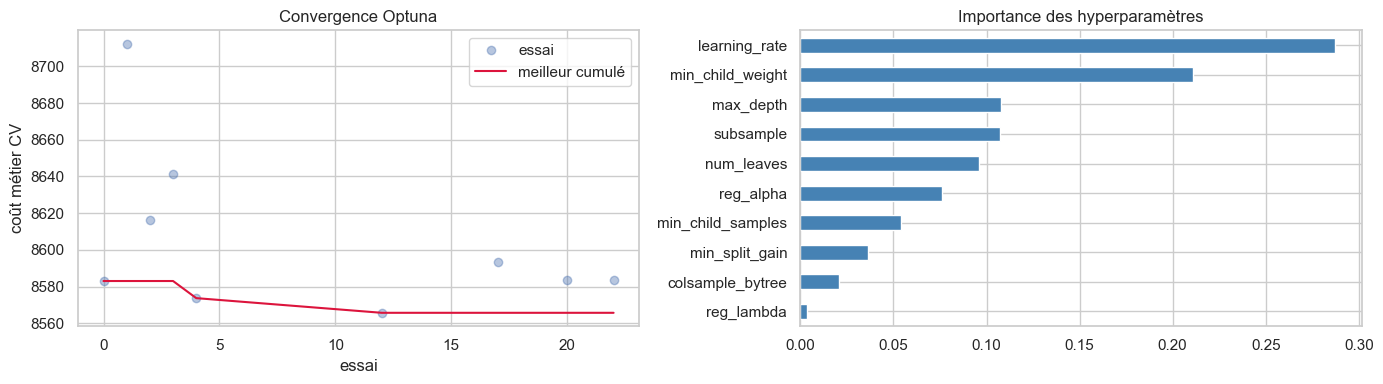

In [4]:
comp = trials[trials.state == 'COMPLETE'].sort_values('number')
best_so_far = comp['value'].cummin()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(comp['number'], comp['value'], 'o', alpha=.4, label='essai')
axes[0].plot(comp['number'], best_so_far, '-', color='crimson', label='meilleur cumulé')
axes[0].set_xlabel('essai'); axes[0].set_ylabel('coût métier CV')
axes[0].set_title('Convergence Optuna'); axes[0].legend()
imp = optuna.importance.get_param_importances(study)
pd.Series(imp).sort_values().plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title("Importance des hyperparamètres")
plt.tight_layout(); plt.show()

## Seuil de décision

Le seuil 0.5 par défaut n'a pas de sens avec un coût asymétrique. Je rebalaye le seuil en OOF (3 folds) avec les hyperparamètres optimaux et je prends le minimum de coût.

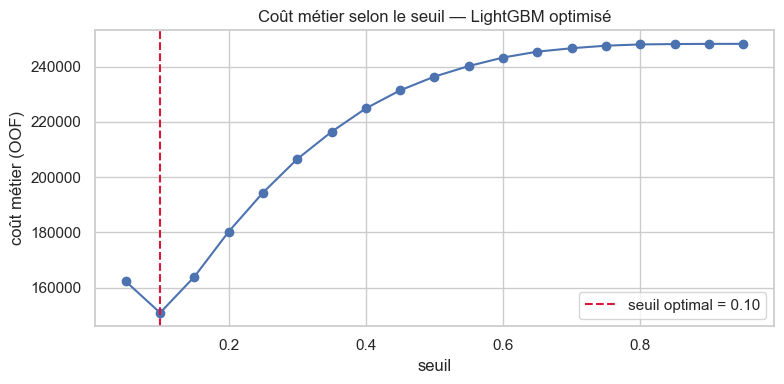

Seuil optimal 0.10 -> coût 150877 (vs 236407 au seuil 0.5)


In [5]:
sweep = pd.read_csv(OUTPUT / 'threshold_sweep.csv')
opt = sweep.loc[sweep.business_cost.idxmin()]
cost_05 = int(sweep.loc[sweep.threshold == 0.5, 'business_cost'].iloc[0])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep.threshold, sweep.business_cost, '-o')
ax.axvline(opt.threshold, color='crimson', ls='--', label=f'seuil optimal = {opt.threshold:.2f}')
ax.set_xlabel('seuil'); ax.set_ylabel('coût métier (OOF)')
ax.set_title('Coût métier selon le seuil — LightGBM optimisé'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Seuil optimal {opt.threshold:.2f} -> coût {int(opt.business_cost)} (vs {cost_05} au seuil 0.5)')

## Optimisé vs version de base

Je compare le LightGBM optimisé au LightGBM de référence de l'Étape 3 (paramètres Aguiar). Les coûts sont ramenés à 1000 clients pour être comparables (la base est mesurée par fold, l'optimisé en OOF sur tout le train).

In [6]:
exp = mlflow.get_experiment_by_name(training.EXPERIMENT_NAME)
runs = mlflow.search_runs([exp.experiment_id])
def metric(run_name, col):
    r = runs[runs['tags.mlflow.runName'] == run_name]
    return float(r[col].iloc[0]) if len(r) and col in runs.columns else np.nan

n_train = int(pq.read_table(OUTPUT / 'feature_dataset.parquet', columns=['TARGET']).to_pandas()['TARGET'].notna().sum())
base_cost_fold = metric('lgbm_gbdt', 'metrics.business_cost_mean')
comparison = pd.DataFrame([
    {'version': 'LightGBM base (Étape 3)', 'seuil': 0.50, 'AUC': metric('lgbm_gbdt', 'metrics.auc_mean'),
     'coût / 1000 clients': base_cost_fold / (n_train / 5) * 1000},
    {'version': 'LightGBM optimisé', 'seuil': 0.50, 'AUC': summary['auc_oof'],
     'coût / 1000 clients': summary['business_cost_threshold_0.5'] / n_train * 1000},
    {'version': 'LightGBM optimisé', 'seuil': summary['optimal_threshold'], 'AUC': summary['auc_oof'],
     'coût / 1000 clients': summary['business_cost_optimal_threshold'] / n_train * 1000},
])
comparison.round(3)

,version,seuil,AUC,coût / 1000 clients
0,LightGBM base (Étape 3),0.5,0.791,764.594
1,LightGBM optimisé,0.5,0.789,768.786
2,LightGBM optimisé,0.1,0.789,490.646


In [7]:
b, t05, topt = comparison['coût / 1000 clients']
print(f'À paramètres optimisés mais seuil 0.5, le coût/1000 passe de {b:.1f} à {t05:.1f}.')
print(f'Le seuil optimal le ramène à {topt:.1f}/1000 clients.')
print('AUC : %.4f (base) vs %.4f (optimisé). Le gros du gain métier vient du seuil.' % (comparison.AUC.iloc[0], comparison.AUC.iloc[1]))

À paramètres optimisés mais seuil 0.5, le coût/1000 passe de 764.6 à 768.8.
Le seuil optimal le ramène à 490.6/1000 clients.
AUC : 0.7909 (base) vs 0.7889 (optimisé). Le gros du gain métier vient du seuil.


## Surapprentissage : courbes d'apprentissage

Je trace l'AUC et la logloss train vs validation au fil des itérations de boosting (modèle optimisé, hold-out 85/15). L'écart train–validation et le plateau de la validation montrent quand le modèle commence à sur-apprendre — c'est là que l'early stopping coupe.

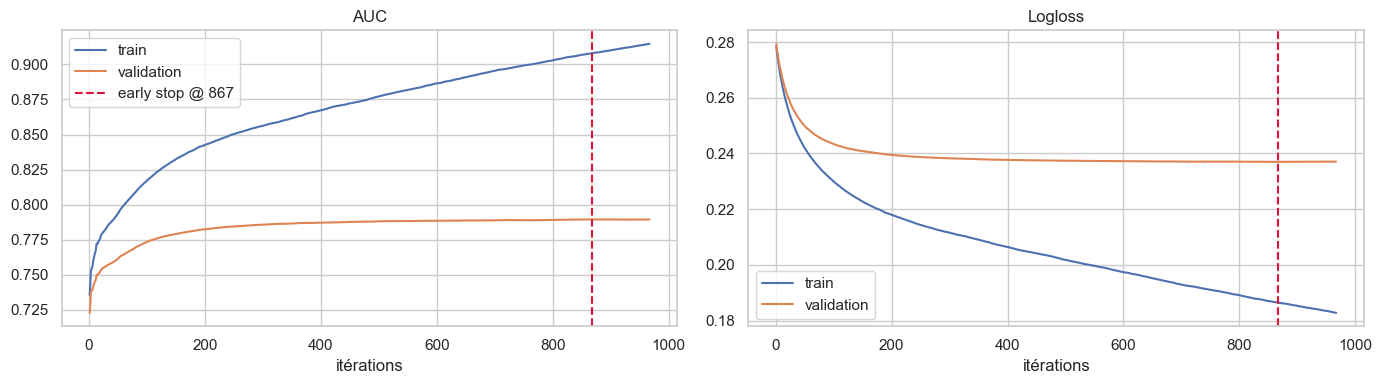

In [8]:
lc = pd.read_csv(OUTPUT / 'learning_curve.csv')
best_iter = summary['best_iteration']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(lc.iteration, lc.train_auc, label='train')
axes[0].plot(lc.iteration, lc.valid_auc, label='validation')
axes[0].axvline(best_iter, color='crimson', ls='--', label=f'early stop @ {best_iter}')
axes[0].set_title('AUC'); axes[0].set_xlabel('itérations'); axes[0].legend()
axes[1].plot(lc.iteration, lc.train_logloss, label='train')
axes[1].plot(lc.iteration, lc.valid_logloss, label='validation')
axes[1].axvline(best_iter, color='crimson', ls='--')
axes[1].set_title('Logloss'); axes[1].set_xlabel('itérations'); axes[1].legend()
plt.tight_layout(); plt.show()

L'AUC d'entraînement grimpe vers 1 tandis que la validation plafonne autour de 0.79 : l'écart est le surapprentissage attendu d'un boosting profond. Les garde-fous sont (1) l'early stopping qui s'arrête au meilleur tour de validation, (2) les pénalités `reg_alpha` / `reg_lambda` et `min_child_*`, (3) le sous-échantillonnage `subsample` / `colsample_bytree`. L'AUC validation reste sous 0.82, seuil au-delà duquel on suspecterait une fuite de données sur ce jeu Kaggle — cohérent avec une absence de leakage. L'écart train/test est volontairement maîtrisé : aucune variable construite à partir de la cible, jointures agrégées par client, et mêmes transformations sur train et test dans `prepare_data.py`.

## Modèle enregistré au Model Registry

`src/optimize_lgbm.py` logue le modèle optimisé et l'enregistre comme version sous `credit-default-lgbm`. C'est la brique reproductible intégrée à la pipeline MLOps.

In [9]:
from mlflow.tracking import MlflowClient
client = MlflowClient()
versions = client.search_model_versions("name='credit-default-lgbm'")
pd.DataFrame([{'version': v.version, 'run_id': v.run_id, 'status': v.status} for v in versions])

,version,run_id,status
0,1,3c64b1734f52401f93ae55ae83d5b2e7,READY
